In [3]:
#importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#chamando tabela e visualizando
tabela_produtos = pd.read_excel('/content/drive/MyDrive/projeto_analise de dados/tabela_dados_robustos.xlsx')
tabela_produtos.head(10)

,ID,Produto,Categoria,Preco,Quantidade,Data_Venda,Ativo,Desconto,Cidade,Metodo_Pagamento
0,1,Notebook,Eletrônicos,1440.95,9,2024-03-12,False,0.17,Belo Horizonte,Boleto
1,2,Cadeira Gamer,Eletrônicos,2374.86,4,2024-11-05,False,0.16,Curitiba,Boleto
2,3,Mouse,Acessórios,2334.76,15,2024-04-30,True,0.20,Belo Horizonte,Pix
3,4,Monitor,Periféricos,3456.39,4,2024-06-29,False,0.15,São Paulo,Pix
4,5,Cadeira Gamer,Eletrônicos,4508.97,4,2024-01-16,True,0.24,Curitiba,Boleto
5,6,Cadeira Gamer,Periféricos,3080.12,4,2024-08-09,False,0.17,Curitiba,Pix
6,7,Cadeira Gamer,Periféricos,929.17,9,2024-05-18,False,0.29,Belo Horizonte,Cartão
7,8,Cadeira Gamer,Periféricos,3721.64,9,2024-02-22,False,0.24,São Paulo,Cartão
8,9,Monitor,Periféricos,1441.61,5,2024-10-15,True,0.26,Curitiba,Pix
9,10,Mouse,Periféricos,492.92,6,2024-01-18,True,0.13,Curitiba,Cartão


In [5]:
#criação do DataFrame da tabela
tabela_df = pd.DataFrame(tabela_produtos)
print(tabela_df)

     ID        Produto    Categoria    Preco  Quantidade  Data_Venda  Ativo  \
0     1       Notebook  Eletrônicos  1440.95           9  2024-03-12  False   
1     2  Cadeira Gamer  Eletrônicos  2374.86           4  2024-11-05  False   
2     3          Mouse   Acessórios  2334.76          15  2024-04-30   True   
3     4        Monitor  Periféricos  3456.39           4  2024-06-29  False   
4     5  Cadeira Gamer  Eletrônicos  4508.97           4  2024-01-16   True   
..  ...            ...          ...      ...         ...         ...    ...   
95   96        Headset  Periféricos   986.88           1  2024-06-18  False   
96   97       Notebook  Periféricos  4152.52           6  2024-07-01  False   
97   98       Notebook  Eletrônicos  4100.53          13  2024-06-04  False   
98   99        Monitor  Periféricos   254.31           7  2024-02-15  False   
99  100        Monitor   Acessórios  3778.44           8  2024-09-13   True   

    Desconto          Cidade Metodo_Pagamento  
0  

In [7]:
#informações gerais sobre a tabela
tabela_produtos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                100 non-null    int64  
 1   Produto           100 non-null    object 
 2   Categoria         100 non-null    object 
 3   Preco             100 non-null    float64
 4   Quantidade        100 non-null    int64  
 5   Data_Venda        100 non-null    object 
 6   Ativo             100 non-null    bool   
 7   Desconto          100 non-null    float64
 8   Cidade            100 non-null    object 
 9   Metodo_Pagamento  100 non-null    object 
dtypes: bool(1), float64(2), int64(2), object(5)
memory usage: 7.3+ KB


In [11]:
#mostrando produtos ativos
tabela_produtos[tabela_df['Ativo'] == True][['Produto', 'Ativo']]

,Produto,Ativo
2,Mouse,True
4,Cadeira Gamer,True
8,Monitor,True
9,Mouse,True
10,Teclado,True
12,Monitor,True
14,Mouse,True
16,Monitor,True
19,Teclado,True
20,Teclado,True


In [13]:
#vendas por metodo de pagamento
tabela_df.groupby('Metodo_Pagamento')['Quantidade'].sum()

,Quantidade
Metodo_Pagamento,
Boleto,367
Cartão,318
Pix,237


In [20]:
#faturamento liquido
tabela_df['Faturamento Liquido']= tabela_df['Preco'] * tabela_df['Quantidade'] * tabela_df['Desconto']
display(tabela_df)

,ID,Produto,Categoria,Preco,Quantidade,Data_Venda,Ativo,Desconto,Cidade,Metodo_Pagamento,Faturamento total,Faturamento Liquido
0,1,Notebook,Eletrônicos,1440.95,9,2024-03-12,False,0.17,Belo Horizonte,Boleto,2204.6535,2204.6535
1,2,Cadeira Gamer,Eletrônicos,2374.86,4,2024-11-05,False,0.16,Curitiba,Boleto,1519.9104,1519.9104
2,3,Mouse,Acessórios,2334.76,15,2024-04-30,True,0.20,Belo Horizonte,Pix,7004.2800,7004.2800
3,4,Monitor,Periféricos,3456.39,4,2024-06-29,False,0.15,São Paulo,Pix,2073.8340,2073.8340
4,5,Cadeira Gamer,Eletrônicos,4508.97,4,2024-01-16,True,0.24,Curitiba,Boleto,4328.6112,4328.6112
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Headset,Periféricos,986.88,1,2024-06-18,False,0.06,São Paulo,Pix,59.2128,59.2128
96,97,Notebook,Periféricos,4152.52,6,2024-07-01,False,0.21,Salvador,Boleto,5232.1752,5232.1752
97,98,Notebook,Eletrônicos,4100.53,13,2024-06-04,False,0.17,Salvador,Boleto,9062.1713,9062.1713
98,99,Monitor,Periféricos,254.31,7,2024-02-15,False,0.17,Rio de Janeiro,Pix,302.6289,302.6289


In [24]:
#dupliquei uma coluna e mudei o nome mas consegui corrigir o erro
display(tabela_df)

,ID,Produto,Categoria,Preco,Quantidade,Data_Venda,Ativo,Desconto,Cidade,Metodo_Pagamento,Faturamento Liquido
0,1,Notebook,Eletrônicos,1440.95,9,2024-03-12,False,0.17,Belo Horizonte,Boleto,2204.6535
1,2,Cadeira Gamer,Eletrônicos,2374.86,4,2024-11-05,False,0.16,Curitiba,Boleto,1519.9104
2,3,Mouse,Acessórios,2334.76,15,2024-04-30,True,0.20,Belo Horizonte,Pix,7004.2800
3,4,Monitor,Periféricos,3456.39,4,2024-06-29,False,0.15,São Paulo,Pix,2073.8340
4,5,Cadeira Gamer,Eletrônicos,4508.97,4,2024-01-16,True,0.24,Curitiba,Boleto,4328.6112
...,...,...,...,...,...,...,...,...,...,...,...
95,96,Headset,Periféricos,986.88,1,2024-06-18,False,0.06,São Paulo,Pix,59.2128
96,97,Notebook,Periféricos,4152.52,6,2024-07-01,False,0.21,Salvador,Boleto,5232.1752
97,98,Notebook,Eletrônicos,4100.53,13,2024-06-04,False,0.17,Salvador,Boleto,9062.1713
98,99,Monitor,Periféricos,254.31,7,2024-02-15,False,0.17,Rio de Janeiro,Pix,302.6289


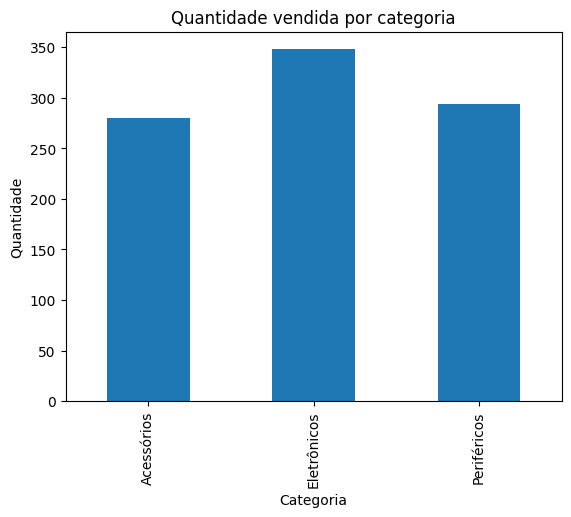

In [27]:
vendas = tabela_df.groupby('Categoria')['Quantidade'].sum()
vendas.plot(kind='bar')
plt.title('Quantidade vendida por categoria')
plt.xlabel('Categoria')
plt.ylabel('Quantidade')
plt.show()